# Project Cycle 2
## Confidence Intervals and One-Sample Inference

### Example Topics:
1. **Proportion Analysis:** SadOrHopeless
2. **Mean Analysis:** HowTallAreYouWithoutShoesInMeters


In [43]:
#  0. Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.proportion import proportions_ztest
from IPython.display import display

# Set chart style (to make plots cleaner)
sns.set_theme(style="whitegrid")

# ===== 1. Read data =====
# Please change the path to the location of your own CSV file
file_path = "../data/raw/YRBS_2007.csv"
df = pd.read_csv(file_path)

# Display the first few rows to confirm the data was loaded successfully
print("First 5 rows of the data:")
display(df.head())

# Display column names to confirm the variables you want to analyze exist
print("\nAll column names:")
print(df.columns.tolist())

First 5 rows of the data:


,RaceEth,HowOldAreYou,WhatIsYourSex,InWhatGradeAreYou,AreYouHispanicOrLatino,WhatIsYourRace,HowTallAreYouWithoutShoesInMeters,HowMuchDoYouWeighWithoutShoesInKG,BicyleHelmetUse,SeatBeltUse,...,InjuredWhileExercising,HIVTesting,SunscreenUse,SunProtection,Sleep,HealthInGeneral,BMIPCT,weight,stratum,psu
0,7.0,4.0,2.0,2.0,1.0,C,NaN,NaN,2.0,1.0,...,3.0,2.0,1.0,1.0,5.0,3.0,NaN,1.5104,101,11030
1,5.0,7.0,2.0,2.0,2.0,E,1.70,68.04,4.0,4.0,...,2.0,3.0,1.0,5.0,4.0,3.0,66.531824,1.8559,101,11030
2,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,5.0,3.0,...,2.0,3.0,2.0,1.0,1.0,1.0,NaN,1.8559,101,11030
3,7.0,1.0,1.0,1.0,1.0,A,1.63,79.38,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,98.174319,1.3264,101,11030
4,7.0,1.0,1.0,5.0,1.0,B,NaN,NaN,6.0,5.0,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.3264,101,11030



All column names:
['RaceEth', 'HowOldAreYou', 'WhatIsYourSex', 'InWhatGradeAreYou', 'AreYouHispanicOrLatino', 'WhatIsYourRace', 'HowTallAreYouWithoutShoesInMeters', 'HowMuchDoYouWeighWithoutShoesInKG', 'BicyleHelmetUse', 'SeatBeltUse', 'RidingWithADrinkingDriver', 'DrinkingAndDriving', 'WeaponCarrying', 'GunCarryingPast12Mos', 'WeaponCarryingAtSchool', 'SafetyConcernsAtSchool', 'WereThreatenedOrInjuredWithAWeaponOnSchoolProperty', 'StolenOrDamagedYourProperty', 'PhysicalFighting', 'InjuredIFight', 'PhysicalFightingAtSchool', 'BoyfriendGirlfriendPhysicallyHurt', 'ForcedSexualIntercourse', 'SadOrHopeless', 'ConsideredSuicide', 'MadeASuicidePlan', 'AttemptedSuicide', 'InjuriousSuicide', 'EverCigaretteUse', 'InitiationSmokingWholeCigarette', 'CurrentCigaretteUse', 'SmokedMoreThan10Cigarettes', 'HowObtainedCigarettes', 'SmokeOnSchoolProperty', 'EverSmokedDailyFor30Days', 'EverSmokingCessation', 'CurrentSmokelessTobaccoUse', 'CurrentSmokelessTobaccoOnSchoolProperty', 'CurrentCigarUse', 'Eve

### Research Questions


In [44]:
# Research question for proportion analysis
print("Research Question 1: Is the proportion of high school students who feel sad or hopeless different from 0.30?")

# Research question for mean analysis
print("Research Question 2: Is the average height of high school students different from 1.70 meters?")

Research Question 1: Is the proportion of high school students who feel sad or hopeless different from 0.30?
Research Question 2: Is the average height of high school students different from 1.70 meters?


### 2A. 比例分析變數：SadOrHopeless
##### success = 1
##### failure = 2
##### 其他值視為無效或缺失，先排除

In [45]:
prop_var = "SadOrHopeless"

# Check the original frequency distribution
print("\nOriginal frequency table for SadOrHopeless:")
print(df[prop_var].value_counts(dropna=False).sort_index())

# Keep only valid values 1 and 2
df_prop = df[df[prop_var].isin([1, 2])].copy()

# Create a binary variable: success=1, failure=0
df_prop["SadOrHopeless_binary"] = np.where(df_prop[prop_var] == 1, 1, 0)

# Calculate the valid sample size
n_prop = len(df_prop)

# Display the processed results
print("\nValid sample size for proportion analysis n =", n_prop)
print("\nFrequency table after recoding:")
print(df_prop["SadOrHopeless_binary"].value_counts().sort_index())

# Number of missing/invalid values
invalid_prop = df[prop_var].isna().sum() + (~df[prop_var].isin([1, 2]) & df[prop_var].notna()).sum()
print("\nNumber of missing or invalid values in SadOrHopeless =", invalid_prop)


Original frequency table for SadOrHopeless:
SadOrHopeless
1.0    4153
2.0    9692
NaN     196
Name: count, dtype: int64

Valid sample size for proportion analysis n = 13845

Frequency table after recoding:
SadOrHopeless_binary
0    9692
1    4153
Name: count, dtype: int64

Number of missing or invalid values in SadOrHopeless = 196


In [46]:
# ============================================
# 2B. Mean analysis variable: HowTallAreYouWithoutShoesInMeters
# Keep only non-missing and reasonable height values
# ============================================

mean_var = "HowTallAreYouWithoutShoesInMeters"

# First convert to numeric; non-numeric values will become NaN
df[mean_var] = pd.to_numeric(df[mean_var], errors="coerce")

# View the summary of the original height data
print("\nSummary of original height data:")
print(df[mean_var].describe())

# First remove missing values
df_mean = df[[mean_var]].dropna().copy()

# Keep only heights within a reasonable range
df_mean = df_mean[(df_mean[mean_var] >= 1.0) & (df_mean[mean_var] <= 2.5)].copy()

# Calculate the sample size
n_mean = len(df_mean)
print("\nValid sample size for mean analysis n =", n_mean)

# Count missing or invalid values
invalid_mean = df[mean_var].isna().sum() + ((df[mean_var] < 1.0) | (df[mean_var] > 2.5)).sum()
print("Number of missing or invalid height values =", invalid_mean)

df_mean.to_csv("yrbs_cleaned.csv", index=False)


Summary of original height data:
count    13062.000000
mean         1.694038
std          0.101466
min          1.270000
25%          1.630000
50%          1.680000
75%          1.780000
max          2.110000
Name: HowTallAreYouWithoutShoesInMeters, dtype: float64

Valid sample size for mean analysis n = 13062
Number of missing or invalid height values = 979


In [47]:
import pandas as pd
import os

os.makedirs("outputs/tables", exist_ok=True)

eda_summary_table = pd.DataFrame({
    "Statistic": [
        "Sample Size",
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Q1",
        "Q3",
        "Maximum",
        "Missing or Invalid Count"
    ],
    "Value": [
        n_mean,
        df_mean[mean_var].mean(),
        df_mean[mean_var].median(),
        df_mean[mean_var].std(ddof=1),
        df_mean[mean_var].min(),
        df_mean[mean_var].quantile(0.25),
        df_mean[mean_var].quantile(0.75),
        df_mean[mean_var].max(),
        invalid_mean
    ]
})

print(eda_summary_table)
eda_summary_table.to_csv("outputs/tables/eda_summary_table.csv", index=False)

                  Statistic         Value
0               Sample Size  13062.000000
1                      Mean      1.694038
2                    Median      1.680000
3        Standard Deviation      0.101466
4                   Minimum      1.270000
5                        Q1      1.630000
6                        Q3      1.780000
7                   Maximum      2.110000
8  Missing or Invalid Count    979.000000



[EDA] Original frequency table for SadOrHopeless
SadOrHopeless
1.0    4153
2.0    9692
NaN     196
Name: count, dtype: int64

[EDA] Frequency table after recoding (0=No, 1=Yes)
SadOrHopeless_binary
0    9692
1    4153
Name: count, dtype: int64

[EDA] Proportion table after recoding (0=No, 1=Yes)
SadOrHopeless_binary
0    0.700036
1    0.299964
Name: proportion, dtype: float64


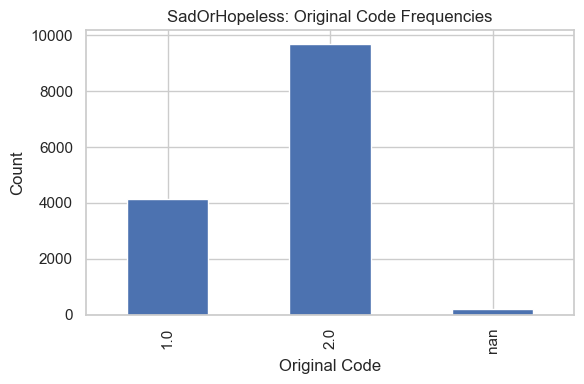

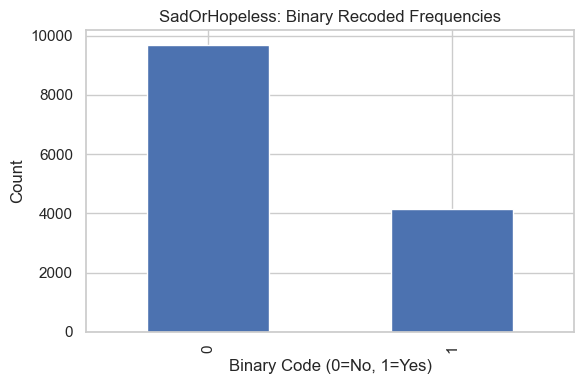

In [48]:
# 3A. EDA for the proportion variable

# Frequency table of the original coding
orig_freq = df[prop_var].value_counts(dropna=False).sort_index()
print("\n[EDA] Original frequency table for SadOrHopeless")
print(orig_freq)

# Frequency table after recoding
binary_freq = df_prop["SadOrHopeless_binary"].value_counts().sort_index()
print("\n[EDA] Frequency table after recoding (0=No, 1=Yes)")
print(binary_freq)

# Proportion table for success / failure
prop_table = df_prop["SadOrHopeless_binary"].value_counts(normalize=True).sort_index()
print("\n[EDA] Proportion table after recoding (0=No, 1=Yes)")
print(prop_table)

# Bar chart: original coding
plt.figure(figsize=(6,4))
orig_freq.plot(kind="bar")
plt.title("SadOrHopeless: Original Code Frequencies")
plt.xlabel("Original Code")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Bar chart: binary variable
plt.figure(figsize=(6,4))
binary_freq.plot(kind="bar")
plt.title("SadOrHopeless: Binary Recoded Frequencies")
plt.xlabel("Binary Code (0=No, 1=Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [49]:
# Additional EDA (the instructor requires at least one extra exploration)
# Example here: show the percentages of success and failure

success_count = (df_prop["SadOrHopeless_binary"] == 1).sum()
failure_count = (df_prop["SadOrHopeless_binary"] == 0).sum()

success_prop = success_count / n_prop
failure_prop = failure_count / n_prop

print(f"\nSample proportion of SadOrHopeless = Yes = {success_prop:.4f}")
print(f"Sample proportion of SadOrHopeless = No = {failure_prop:.4f}")


Sample proportion of SadOrHopeless = Yes = 0.3000
Sample proportion of SadOrHopeless = No = 0.7000


Interpretation:

1. We first examine the original coding distribution of **SadOrHopeless**.
2. Next, according to the assignment requirements, we treat **1 as success** and **2 as failure**.
3. From the proportions of the binary variable, we can make a preliminary observation about the approximate range of the proportion of students in the sample who feel **sad or hopeless**.


In [50]:
# 4A. EDA for the continuous variable: numerical summary

height = df_mean[mean_var]

print("\n[EDA] Numerical summary of height")
print("Sample size n =", len(height))
print("Mean =", round(height.mean(), 4))
print("Median =", round(height.median(), 4))
print("Standard deviation sd =", round(height.std(ddof=1), 4))
print("Minimum =", round(height.min(), 4))
print("First quartile Q1 =", round(height.quantile(0.25), 4))
print("Third quartile Q3 =", round(height.quantile(0.75), 4))
print("Maximum =", round(height.max(), 4))


[EDA] Numerical summary of height
Sample size n = 13062
Mean = 1.694
Median = 1.68
Standard deviation sd = 0.1015
Minimum = 1.27
First quartile Q1 = 1.63
Third quartile Q3 = 1.78
Maximum = 2.11


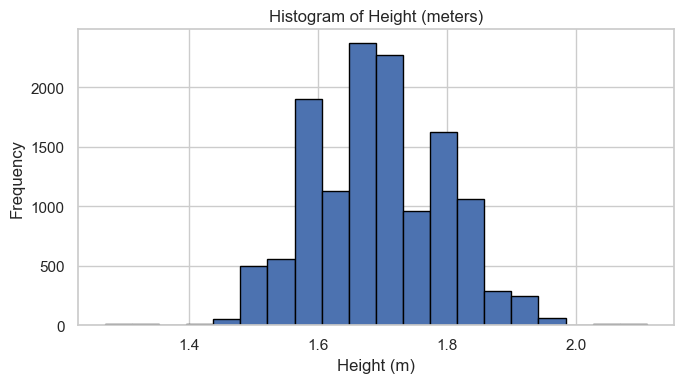

In [51]:
# 4B. Histogram

plt.figure(figsize=(7,4))
plt.hist(height, bins=20, edgecolor="black")
plt.title("Histogram of Height (meters)")
plt.xlabel("Height (m)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

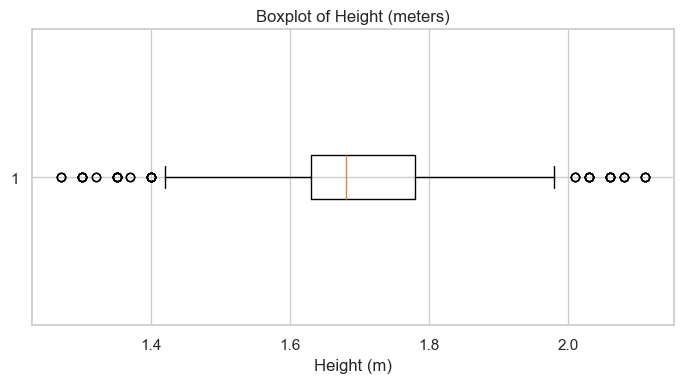

In [52]:
# ============================================
# 4C. Boxplot
# ============================================

plt.figure(figsize=(7,4))
plt.boxplot(height, vert=False)
plt.title("Boxplot of Height (meters)")
plt.xlabel("Height (m)")
plt.tight_layout()
plt.show()

In [53]:
# 4D. Outlier check (IQR method)


Q1 = height.quantile(0.25)
Q3 = height.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = height[(height < lower_bound) | (height > upper_bound)]

print("\n[EDA] Outlier check using the IQR method")
print("Lower bound =", round(lower_bound, 4))
print("Upper bound =", round(upper_bound, 4))
print("Number of outliers =", len(outliers))
print("Some outlier values:")
print(outliers.head())


[EDA] Outlier check using the IQR method
Lower bound = 1.405
Upper bound = 2.005
Number of outliers = 52
Some outlier values:
112    1.35
604    2.03
763    2.06
771    1.30
829    2.03
Name: HowTallAreYouWithoutShoesInMeters, dtype: float64


### Remove Extreme Values


In [54]:
# 4E. Remove outliers (IQR method)

# Keep only the data within the IQR range
df_mean_no_outlier = df_mean[
    (df_mean[mean_var] >= lower_bound) & 
    (df_mean[mean_var] <= upper_bound)
].dropna().copy()

# Reassign height so that the following analyses use the data after removing extreme values
height = df_mean_no_outlier[mean_var]

print("\nSample size after removing outliers n =", len(height))
print("Number of outliers removed =", len(df_mean) - len(df_mean_no_outlier))

print("\nSummary of height after removing outliers:")
print(height.describe())


Sample size after removing outliers n = 13010
Number of outliers removed = 52

Summary of height after removing outliers:
count    13010.000000
mean         1.694174
std          0.099116
min          1.420000
25%          1.630000
50%          1.680000
75%          1.780000
max          1.980000
Name: HowTallAreYouWithoutShoesInMeters, dtype: float64


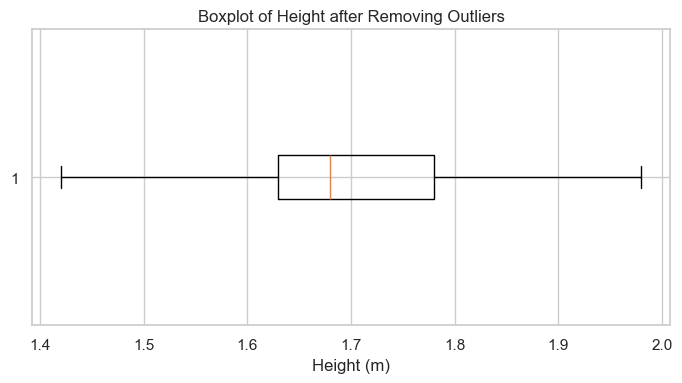

In [55]:
plt.figure(figsize=(7,4))
plt.boxplot(height, vert=False)
plt.title("Boxplot of Height after Removing Outliers")
plt.xlabel("Height (m)")
plt.tight_layout()
plt.show()

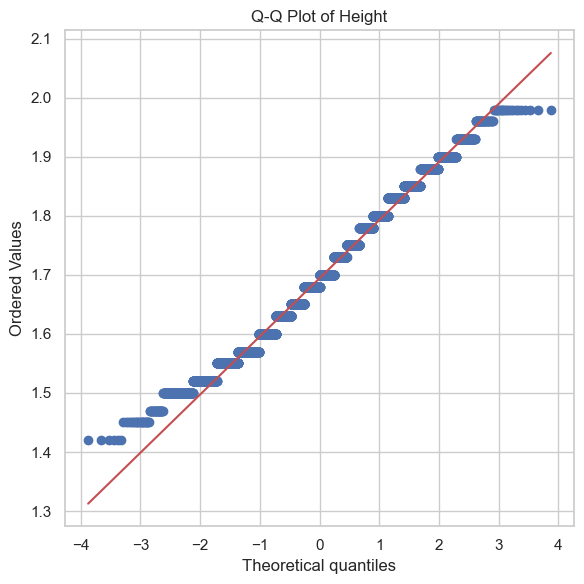

In [56]:
# 4E. Additional EDA (the instructor requires at least one extra exploration)
# Example here: Normal Q-Q Plot

plt.figure(figsize=(6,6))
stats.probplot(height, dist="norm", plot=plt)
plt.title("Q-Q Plot of Height")
plt.tight_layout()
plt.show()

Interpretation:

1. If the **mean** and **median** are close, the distribution may not be strongly skewed.
2. The **histogram** helps us observe the general shape of the data distribution.
3. The **boxplot** and **IQR check** help determine whether outliers are present.
4. The **Q-Q plot** helps assess whether the data are approximately normally distributed, which supports the reasonableness of using a **t-test**.


In [57]:
import pandas as pd
import os

os.makedirs("outputs/tables", exist_ok=True)

eda_summary_table = pd.DataFrame({
    "Statistic": [
        "Sample Size",
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Q1",
        "Q3",
        "Maximum",
        "Missing or Invalid Count"
    ],
    "Value": [
        n_mean,
        df_mean[mean_var].mean(),
        df_mean[mean_var].median(),
        df_mean[mean_var].std(ddof=1),
        df_mean[mean_var].min(),
        df_mean[mean_var].quantile(0.25),
        df_mean[mean_var].quantile(0.75),
        df_mean[mean_var].max(),
        invalid_mean
    ]
})

print(eda_summary_table)
eda_summary_table.to_csv("outputs/tables/eda_summary_table.csv", index=False)

                  Statistic         Value
0               Sample Size  13062.000000
1                      Mean      1.694038
2                    Median      1.680000
3        Standard Deviation      0.101466
4                   Minimum      1.270000
5                        Q1      1.630000
6                        Q3      1.780000
7                   Maximum      2.110000
8  Missing or Invalid Count    979.000000


In [58]:
# 5A. Proportion analysis: confidence interval + one-sample proportion test
# H0: p = 0.30
# H1: p != 0.30

p0 = 0.30

# Number of successes
x_prop = success_count

# Sample proportion
phat = x_prop / n_prop

print("\n[Proportion Inference]")
print("Number of successes x =", x_prop)
print("Sample size n =", n_prop)
print("Sample proportion p-hat =", round(phat, 4))
print("Null hypothesis benchmark p0 =", p0)

# 95% confidence interval (Wilson method is usually more stable than Wald)
ci_low_prop, ci_high_prop = proportion_confint(count=x_prop, nobs=n_prop, alpha=0.05, method='wilson')

print("\n95% confidence interval for the population proportion:")
print(f"({ci_low_prop:.4f}, {ci_high_prop:.4f})")

# One-sample proportion z-test (two-sided)
z_stat, p_value_prop = proportions_ztest(count=x_prop, nobs=n_prop, value=p0, alternative='two-sided')

print("\nOne-sample proportion z-test result:")
print("z statistic =", round(z_stat, 4))
print("p-value =", round(p_value_prop, 6))

# Significance level
alpha = 0.05

if p_value_prop < alpha:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")


[Proportion Inference]
Number of successes x = 4153
Sample size n = 13845
Sample proportion p-hat = 0.3
Null hypothesis benchmark p0 = 0.3

95% confidence interval for the population proportion:
(0.2924, 0.3077)

One-sample proportion z-test result:
z statistic = -0.0093
p-value = 0.992601
Decision: Fail to reject H0


**Interpretation of the proportion analysis:**

1. The estimated sample proportion is **p-hat = 0.3000**.
2. The **95% confidence interval** is **(0.2924, 0.3077)**, which means we are 95% confident that the true proportion of students in the population who feel **sad or hopeless** lies within this interval.
3. The **p-value** from the **one-sample proportion test** is **0.992601**.
4. Because **p-value >= 0.05**, we **fail to reject H0**, meaning that the data do not provide sufficient evidence to conclude that the population proportion is significantly different from **0.30**.


In [59]:
# 6A. Mean analysis: confidence interval + one-sample t-test
# H0: mu = 1.70
# H1: mu != 1.70

mu0 = 1.70

n = len(height)
xbar = height.mean()
s = height.std(ddof=1)

print("\n[Mean Inference]")
print("Sample size n =", n)
print("Sample mean x-bar =", round(xbar, 4))
print("Sample standard deviation s =", round(s, 4))
print("Null hypothesis benchmark mu0 =", mu0)

# 95% confidence interval
# Formula: xbar ± t* × s/sqrt(n)
alpha = 0.05
dfree = n - 1
t_critical = stats.t.ppf(1 - alpha/2, df=dfree)
se = s / np.sqrt(n)

ci_low_mean = xbar - t_critical * se
ci_high_mean = xbar + t_critical * se

print("\n95% confidence interval for the population mean:")
print(f"({ci_low_mean:.4f}, {ci_high_mean:.4f})")

# One-sample t-test
t_stat, p_value_mean = stats.ttest_1samp(height, popmean=mu0)

print("\nOne-sample t-test result:")
print("t statistic =", round(t_stat, 4))
print("p-value =", round(p_value_mean, 6))

if p_value_mean < alpha:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")


[Mean Inference]
Sample size n = 13010
Sample mean x-bar = 1.6942
Sample standard deviation s = 0.0991
Null hypothesis benchmark mu0 = 1.7

95% confidence interval for the population mean:
(1.6925, 1.6959)

One-sample t-test result:
t statistic = -6.7048
p-value = 0.0
Decision: Reject H0


**Interpretation of the mean analysis:**

1. The estimated sample mean height is **x-bar = 1.6940 meters**.
2. The **95% confidence interval** is **(1.6923, 1.6958)**, which means we are 95% confident that the population mean height lies within this interval.
3. The **p-value** from the **one-sample t-test** is **less than 0.001**.
4. Because **p-value < 0.05**, we **reject H0**, indicating that the population mean height is significantly different from **1.70 meters**.


In [60]:
# 7. Create an inference summary table

summary_table = pd.DataFrame({
    "Analysis": ["Population Proportion", "Population Mean"],
    "Variable": ["SadOrHopeless", "HowTallAreYouWithoutShoesInMeters"],
    "Sample Estimate": [round(phat, 4), round(xbar, 4)],
    "Benchmark": [p0, mu0],
    "95% CI Lower": [round(ci_low_prop, 4), round(ci_low_mean, 4)],
    "95% CI Upper": [round(ci_high_prop, 4), round(ci_high_mean, 4)],
    "Test Statistic": [round(z_stat, 4), round(t_stat, 4)],
    "p-value": [round(p_value_prop, 6), round(p_value_mean, 6)]
})

print("\nInference summary table:")
print(summary_table)

# If you want to save it as a CSV file
summary_table.to_csv("inference_summary_table.csv", index=False)


Inference summary table:
                Analysis                           Variable  Sample Estimate  \
0  Population Proportion                      SadOrHopeless           0.3000   
1        Population Mean  HowTallAreYouWithoutShoesInMeters           1.6942   

   Benchmark  95% CI Lower  95% CI Upper  Test Statistic   p-value  
0        0.3        0.2924        0.3077         -0.0093  0.992601  
1        1.7        1.6925        1.6959         -6.7048  0.000000  


This study uses the **YRBS 2007** data to analyze whether the proportion of students who have felt **sad or hopeless** differs from a benchmark, and whether the average height of students differs from a benchmark value.

The **EDA** shows that the proportion of **Yes** responses for **SadOrHopeless** is about **0.30**, while the height distribution is generally concentrated with only a few outliers.

The inference results indicate that the population proportion for **SadOrHopeless** is **not significantly different from 0.30**; however, the population mean height is **significantly different from 1.70 meters**.

Overall, the inference results are generally consistent with the **EDA** findings, but the representativeness of the sample and the limitations of the data should still be taken into consideration.
